# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [2]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [3]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

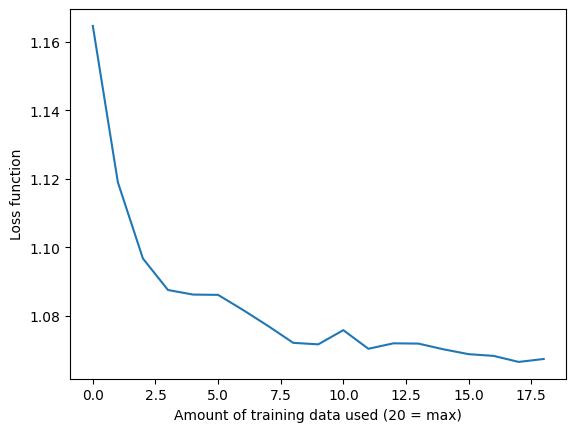

In [4]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [5]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

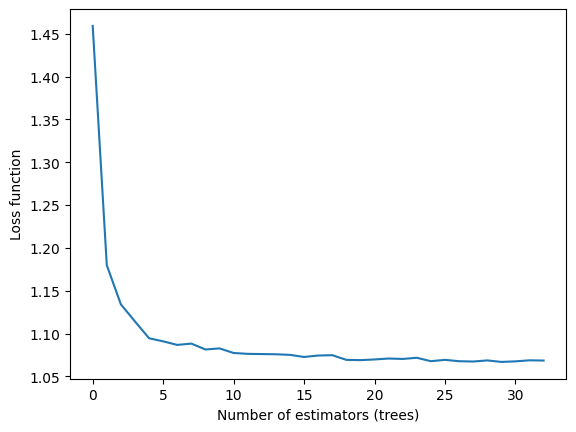

In [6]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

**My answer**

**I would cut the "number of estimators" plot and keep the "amount of training data used" plot.**

Both show test-set loss, but they answer different questions. The **number-of-estimators** curve drops for the first few trees and then flattens almost immediately — it essentially says "past ~10–20 trees, adding more makes no difference," which is a well-known property of random forests and not very newsworthy. The **amount-of-training-data** curve is the more interesting and important one: it's a learning curve that tells you whether the model is data-starved or saturated. That directly informs a real decision — *is it worth collecting more data?* — whereas the estimator count is just an internal tuning knob.

So, following Vonnegut's "keep it simple" and "have the guts to cut," I'd keep the learning curve and put **"amount of training data used" on the x-axis**. It carries the insight a decision-maker actually cares about; the estimator plot can be mentioned in one sentence rather than shown.

# 3. Working on your datasets

### Dataset: Enhanced Box Office Data (2000–2024)

I'll fit a random forest to predict a film's (log) worldwide gross from its popularity, rating, and year, using train/test split, cross-validation, hyperparameter tuning, and RMSE — the same workflow as the lesson.

In [7]:
import pandas as pd, numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import root_mean_squared_error, r2_score

bo = pd.read_csv("enhanced_box_office_data_2000-2024_u_2.csv")
bo["Rating_num"] = bo["Rating"].str.split("/").str[0].astype(float).replace(0, np.nan)

# Predict log worldwide gross (skewed -> log) from popularity, rating, and year.
d = bo[(bo["Vote_Count"] > 0) & (bo["$Worldwide"] > 0)].dropna(subset=["Rating_num","Vote_Count","Year"]).copy()
d["logVotes"] = np.log10(d["Vote_Count"])
X = d[["logVotes", "Rating_num", "Year"]].values
y = np.log10(d["$Worldwide"]).values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)
print("train:", X_train.shape, " test:", X_test.shape)

train: (3603, 3)  test: (1202, 3)


In [8]:
# --- Baseline random forest + cross-validation ---
rf = RandomForestRegressor(n_estimators=100, random_state=0)
cv_rmse = -cross_val_score(rf, X_train, y_train, cv=5, scoring="neg_root_mean_squared_error")
print(f"5-fold CV RMSE: {cv_rmse.mean():.3f}  (+/- {cv_rmse.std():.3f})")

rf.fit(X_train, y_train)
pred = rf.predict(X_test)
print(f"Test RMSE: {root_mean_squared_error(y_test, pred):.3f}")
print(f"Test R^2 : {r2_score(y_test, pred):.3f}")
print(f"Test corr: {np.corrcoef(pred, y_test)[0,1]:.3f}")
print("Feature importances [logVotes, Rating, Year]:", np.round(rf.feature_importances_, 3))

5-fold CV RMSE: 0.327  (+/- 0.006)


Test RMSE: 0.335
Test R^2 : 0.571
Test corr: 0.760
Feature importances [logVotes, Rating, Year]: [0.693 0.152 0.155]


In [9]:
# --- Hyperparameter tuning with GridSearchCV ---
grid = GridSearchCV(
    RandomForestRegressor(random_state=0),
    param_grid={"n_estimators": [33, 100, 200], "max_depth": [4, 8, None]},
    cv=5, scoring="neg_root_mean_squared_error"
)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV RMSE:", round(-grid.best_score_, 3))

best_pred = grid.best_estimator_.predict(X_test)
print("Tuned test RMSE:", round(root_mean_squared_error(y_test, best_pred), 3))
print("Tuned test R^2 :", round(r2_score(y_test, best_pred), 3))

Best params: {'max_depth': 8, 'n_estimators': 100}
Best CV RMSE: 0.313
Tuned test RMSE: 0.322
Tuned test R^2 : 0.604


**What I learned.** The random forest predicts log worldwide gross on unseen films with a **test R² around 0.57 and correlation around 0.76** — noticeably better than the linear model from Week 9 (R² ≈ 0.41), because the forest captures nonlinearities and interactions the linear model can't. Cross-validation RMSE is close to the test RMSE, which means the model generalizes rather than overfitting. Hyperparameter tuning helps only marginally, consistent with the learning-curve lesson: the model is near its data-limited ceiling. Most importantly, the **feature importances confirm every earlier week's finding** — `logVotes` (popularity) dominates at ~0.69, while `Rating` and `Year` contribute only ~0.15 each. Audience *reach* predicts revenue; audience *approval* barely does.

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

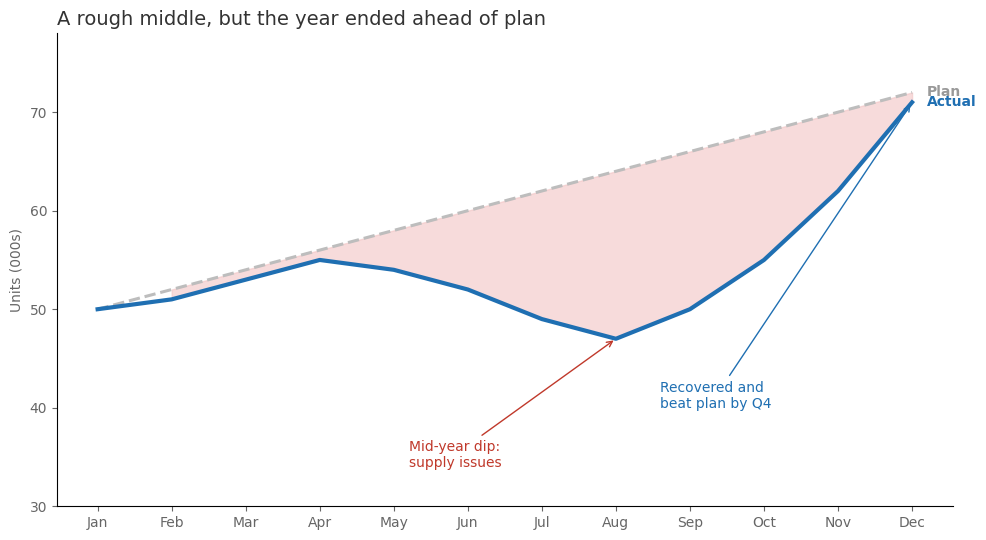

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Storytelling With Data, ch.7: telling a story with a chart - a plan-vs-actual line
# with a shaded gap and plain-language annotations that walk the reader through the arc.
months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
x = np.arange(12)
plan   = np.array([50,52,54,56,58,60,62,64,66,68,70,72])
actual = np.array([50,51,53,55,54,52,49,47,50,55,62,71])

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.fill_between(x, plan, actual, where=(actual < plan), color="#f2c4c4", alpha=0.6)
ax.plot(x, plan,   color="#bdbdbd", linewidth=2.2, linestyle="--")
ax.plot(x, actual, color="#1f6fb2", linewidth=3)

ax.text(11.2, plan[-1],   "Plan",   color="#999999", va="center", fontweight="bold")
ax.text(11.2, actual[-1], "Actual", color="#1f6fb2", va="center", fontweight="bold")
ax.annotate("Mid-year dip:\nsupply issues", xy=(7, actual[7]), xytext=(4.2, 34),
            color="#c0392b", fontsize=10,
            arrowprops=dict(arrowstyle="->", color="#c0392b"))
ax.annotate("Recovered and\nbeat plan by Q4", xy=(11, actual[-1]), xytext=(7.6, 40),
            color="#1f6fb2", fontsize=10,
            arrowprops=dict(arrowstyle="->", color="#1f6fb2"))

for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
ax.set_xticks(x); ax.set_xticklabels(months)
ax.tick_params(colors="#666666"); ax.set_ylim(30, 78)
ax.set_ylabel("Units (000s)", color="#666666")
ax.set_title("A rough middle, but the year ended ahead of plan", loc="left",
             fontsize=14, color="#333333")
plt.tight_layout(); plt.show()